# MIT91207 Machine Learning

Name: Mugisha Jean Claude
Registration number: 26016815
Programme: MSc Information Technology, Level 9
Module: MIT91207 Machine Learning
Lecturer: Dr Gustave Udahemuka


## How to read this

Every figure quoted below is produced by a script in `code/` and executed in this
notebook. Nothing is asserted that is not measured. Where a result contradicts the
argument I was about to make, the result is reported and the argument is changed.

| | |
|---|---|
| Python | 3.9.6, seed 42 throughout |
| Libraries | pandas, numpy, scikit-learn, statsmodels, scipy, matplotlib |
| Question One | No dataset supplied, so a farm-season panel is generated under a stated process |
| Question Four | `data/loan.csv`, 20,000 applicants, 34 variables |
| Question Five | `data/crimes.csv`, 2,215 communities, 144 variables |

In [1]:
# Environment check. Every result in this notebook is produced by the cells below.
%matplotlib inline
import sys, os, pandas, numpy, sklearn, statsmodels, scipy, matplotlib
print('python      ', sys.version.split()[0])
for m in (pandas, numpy, sklearn, statsmodels, scipy, matplotlib):
    print(f'{m.__name__:12s}', m.__version__)
print('\nproject folder:', os.path.basename(os.getcwd()))
print('datasets      :', sorted(f for f in os.listdir('data') if f.endswith('.csv')))

# Two expected warnings are silenced so the output stays readable:
#   ConvergenceWarning, raised where a model is deliberately fitted on data
#     carrying no signal (Question Four, pre-decision feature set).
#   UserWarning from the encoder, raised where a resampled subset happens to
#     contain none of a rare category.
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

python       3.9.6
pandas       2.3.3
numpy        2.0.2
sklearn      1.6.1
statsmodels  0.14.6
scipy        1.13.1
matplotlib   3.9.4

project folder: MIT91207 ML CAT - Mugisha 26016815 - 2026-09-21
datasets      : ['crimes.csv', 'length_of_stay.csv', 'loan.csv', 'telecom_customer_expenditure.csv']


# SECTION A

# Question One: agricultural low-yield early warning

## 1(a) Evaluating the proposal to deploy on predictive performance alone

The proposal fails on a definitional point before any of the practical objections
land. "Highest overall performance" is not a property a model has. It is a number
produced by a choice of metric, a choice of validation scheme and a choice of test
sample, and every one of those choices is contestable. A model that tops the table
under one protocol can sit mid-table under another. So the proposal is not merely
risky; as stated it does not specify a decision rule at all.

Beyond that, four factors need settling before anything is deployed.

### Validation protocol decides the ranking, and this data breaks the usual one

Farms recur across seasons. A holdout drawn at random over farm-season rows puts the
same farm on both sides of the split, so the model is rewarded for recognising farms
it has already been fitted to. The demonstration in 1(c) measures this on the
generated panel: a random split reports AUC 0.7105 against 0.6912 for a split grouped
by farm, an optimism of 0.0193 with 1,694 of 1,800 farms appearing on both sides.
Whichever model "wins" under the careless protocol may simply be the model that
memorises hardest. The ranking has to be re-derived under a grouped and
forward-in-time protocol before it means anything.

### The operating point matters more than the ranking

Field officers cannot visit every farm. If the advisory capacity is, say, the top
quartile of risk, then what matters is precision and recall at that cut-off, not the
area under a curve that averages over thresholds the company will never use. The two
errors are also priced very differently. A missed low-yield farm costs a smallholder
a season of income. A false alarm costs an officer a morning. Any metric that weights
these equally, which includes accuracy and to a lesser degree AUC, encodes a
preference the company has not stated and would not endorse if asked.

### Coverage is unequal, so an average conceals who the model fails

In the generated panel the district shares run from 34.0% for Nyagatare down to 4.6%
for Karongi, and missing fertiliser records run the other way, from 4.3% to 28.6%.
A single headline number is dominated by the districts that contributed most of the
data. The subgroup audit in 1(e) is the check that has to pass, and the intervals in
that table are wide enough that several apparent differences are not differences at
all.

### The model will be obsolete on a schedule, and nobody has set the schedule

The scenario states that weather patterns have changed. Section 1(d) shows what that
does: performance holds between AUC 0.735 and 0.767 across the six seasons the model
was fitted on, then drops to between 0.654 and 0.686 once the rainfall regime shifts.
Deploying "immediately" without a retraining trigger, a monitoring plan and an owner
is deploying an asset that decays silently.

Two further considerations sit outside the modelling but decide whether the system is
acceptable.

Predictions here allocate scarce inputs to smallholders, so a farm flagged as low risk
may be denied fertiliser or pest support it would have received under the previous
process. That is a consequential decision about a household's income, and it needs a
stated appeal route and a human decision-maker who can override the model. Field
officers also need to know why a farm was flagged, because "the model says so" is not
an instruction anyone can act on. A ranked list with the two or three drivers attached
is usable; a bare probability is not.

Finally, the model predicts association, not effect. Farms with low fertiliser use
have lower yields, but that does not establish that supplying fertiliser to a flagged
farm raises its yield by the amount the model implies. Establishing that requires a
trial, and the company should run one on a subset before scaling the intervention.

## 1(b) Formulating the problem

The decision the company is making is a triage decision under a capacity constraint:
which farms does a field officer visit before planting. That framing, and not the data, should determine the target.

### As classification

Target: `low_yield`, a binary indicator that the farm's yield for the coming season
falls below a stated threshold, for example the 25th percentile of yield for that crop
and district in recent seasons. Note that the threshold has to be defined relative to
a district and a crop, because an absolute tonnes-per-hectare cut-off would flag
entire low-potential districts every season and tell the company nothing it did not
already know.

A calibrated probability from this model supports the decision directly. Farms are
ranked, the top N by risk are assigned to officers where N is the visit capacity, and
the probability itself can be banded into act, monitor and no-action tiers. Because
the output is calibrated, "0.7" can be audited against the observed rate among farms
given that score, which is what makes the number defensible to a manager.

### As regression

Target: `yield_kg_per_ha`, the continuous yield for the coming season.

This supports a different and complementary decision. The classifier says whether to
intervene; the regression says how much is at stake. A farm predicted at 15% below its
district threshold and a farm predicted at 60% below are both "at risk", and the
classifier cannot distinguish them, yet they justify very different responses. The
continuous prediction also allows the company to estimate the tonnage at risk across a
district, which is what an operations manager needs for planning fertiliser volumes instead of officer visits.

### The recommendation

Fit the regression on the continuous yield and derive the classification by thresholding it, instead of fitting a separate classifier. The underlying quantity is
continuous and the binary label is an administrative convention applied to it, so
modelling the convention discards information. Running both is reasonable in practice,
and disagreement between them is a useful signal that a farm is atypical and deserves
human review.

One caveat that applies to both framings: the prediction must be made at a point in
the season when intervention is still possible. A model that uses rainfall over the
whole season predicts a yield that has already happened. The feature set is therefore a
function of the decision date, and everything observed after it is unusable no matter
how predictive.

## 1(c) A leakage-safe workflow, and why the order matters

Leakage is not one failure. It is at least four, they enter at different points, and
the order of operations is what keeps each of them out. The workflow below is stated
in the order it must run, with the reason each step sits where it does.

Step 1. Fix the decision date and discard everything observed after it. For a
pre-planting warning the model may use soil, farm size, seed variety, irrigation
status, prior-season yields and the long-run climate normals for the location. It may
not use realised rainfall for the season being predicted, harvest-time pest counts, or
the yield of the neighbouring plot recorded at harvest. This is first because no later
step can repair it. A feature that does not exist at decision time produces a model
that validates well and cannot be served.

Step 2. Split by farm and by time, before touching the data. Farms recur, so the
split is grouped on `farm_id`. Seasons progress, so the test period follows the
training period. Splitting first is what makes every subsequent statistic honest.

Step 3. Fit imputation on the training rows only. Median fertiliser is computed on
training farms and applied unchanged to the test rows. A missingness indicator is
retained, because in this panel the gaps are not random: they run from 4.3% in
Nyagatare to 28.6% in Karongi, so absence encodes district and extension-service
coverage.

Step 4. Fit scaling on the training rows only. Rainfall has a standard deviation
of 141 against 0.53 for soil pH, a ratio of roughly 265 to 1. Any distance-based or
penalised method is otherwise dominated by rainfall for reasons of measurement units.

Step 5. Encode categorical variables with the training vocabulary. District and
seed variety are nominal. An unseen category at scoring time must map to a defined
value rather than raise, and it must be distinguishable from a legitimate reference
level.

Step 6. Select features inside the cross-validation loop, not before it. Ranking
predictors on the full dataset and then cross-validating the winners reports the error
of the selection, not of the procedure.

Step 7. Evaluate once on the held-out period.

### What the measurement actually shows

The textbook warning is that steps 3 and 4 must follow step 2. On this panel that
warning is worth nothing:

```
preprocess then split  AUC = 0.7119
split then preprocess  AUC = 0.7119
difference            +0.0000
```

A median over 18,000 rows and a standard deviation over 18,000 rows barely move when
4,500 of them are removed, so the leak exists but is too small to measure. That is a
property of these statistics and this sample size, not a general result. Replace the
median with a target encoder, or run the same test on 200 rows, and the gap opens
immediately.

The leak that does bite is the one the textbook mentions less:

```
random split over farm-seasons   AUC = 0.7105   farms on both sides: 1,694
grouped by farm                  AUC = 0.6912   farms on both sides: 0
optimism                        +0.0193
```

Nearly every farm appears on both sides of a random split, and the reported score is
0.0193 higher as a result. The practical lesson is that the ordering rule people
recite is the cheap one, and the grouping rule people forget is the expensive one.

## 1(d) Diagnosing and responding to decay

The two kinds of change have to be separated because they call for different responses,
and only one of them is visible without labels.

Covariate shift is a change in the distribution of the inputs. The relationship
between predictors and yield is intact; the model is simply being asked about farms
unlike those it was fitted on. It is detectable immediately, from unlabelled data.

Concept drift is a change in the relationship itself. The same rainfall now implies
a different yield. It is invisible in the inputs and only becomes measurable once
outcomes arrive, which in agriculture means a season later.

Both are present in the panel, and separating them is the point:

```
input drift, predictors only
  rainfall_mm      KS 0.308  p 0.00e+00    mean 877.4 -> 787.1
  temperature_c    KS 0.173  p 2.01e-113   mean  19.7 ->  20.2
  pest_reports     KS 0.242  p 2.62e-222   mean   1.4 ->   2.2

relationship drift, the coefficient itself
  2016-2021: coefficient on standardised rainfall = -0.4262
  2022-2025: coefficient on standardised rainfall = -0.2206
```

Rainfall fell by about 90 mm and the coefficient on it roughly halved. Those are two
separate failures happening together. A monitoring system watching only input
distributions would have raised an alarm on the first and stayed silent on the second,
while concluding, wrongly, that it had characterised the problem.

The consequence for performance:

```
2016-2021 (fitted period)   AUC 0.735 to 0.767
2022-2025 (after the shift) AUC 0.654 to 0.686
```

### Monitoring and response

Monitoring runs at three levels, because each catches something the others miss.

At the input level, a Kolmogorov-Smirnov or population-stability check per predictor,
per season, against the training distribution. This is cheap, needs no labels, and
fires immediately. The thresholds should be calibrated on the historical
season-to-season variation instead of a textbook constant, since agricultural
inputs vary substantially between years without anything being wrong.

At the prediction level, the distribution of predicted risk and the flag rate per
district. A model whose flagged share jumps without a corresponding change in inputs
is behaving differently for a reason worth finding.

At the outcome level, AUC, calibration and precision or recall at the operating
threshold, computed per season as harvest data lands. This is the only level that
detects concept drift, and it is necessarily a season behind.

The response ladder should be agreed in advance so that nobody is negotiating under
pressure. Recalibration first, which re-fits the mapping from score to probability and
is cheap. Refitting on a rolling window next, the correct response to concept
drift and implies discarding the oldest seasons instead of accumulating them.
Re-specification last, if the drivers themselves have changed, for example if
irrigation has become the dominant factor in a way the original feature set did not
anticipate.

Two design choices reduce exposure before any of this is needed. Weighting recent
seasons more heavily in training accepts a little variance for a large reduction in
staleness. And holding out the most recent season as the test set at every refit means
the reported performance is always an estimate of next season and not of the past.

One caution that applies to the whole scheme: once field officers act on the
predictions, successful interventions prevent the outcomes the model predicts, and
measured performance falls even though the system is working. Unless the intervention
is recorded as a variable, retraining will progressively unlearn the signal that made
the system useful.

## 1(e) Is the regional difference real, or is it the model?

The question cannot be answered by looking at the flag rates, because a difference in
flag rates is exactly what a correct model produces when the underlying rates differ.
The investigation has to separate three candidate explanations.

First, establish the ground truth rate per district. On the held-out farms:

```
 district    n  true rate  flag rate    AUC   recall  precision  missing fert.  AUC 95% CI
     Huye  410      0.688      0.254  0.700    0.323      0.875          0.235  0.650-0.749
 Bugesera  720      0.685      0.444  0.688    0.529      0.816          0.108  0.646-0.729
  Kayonza 1040      0.636      0.238  0.669    0.309      0.823          0.062  0.641-0.699
  Karongi  200      0.635      0.355  0.722    0.472      0.845          0.286  0.643-0.790
Nyagatare 1420      0.597      0.186  0.690    0.245      0.788          0.043  0.665-0.721
  Musanze  710      0.573      0.166  0.688    0.226      0.780          0.130  0.650-0.726
```

The flag rate spans 0.278 while the true low-yield rate spans 0.115, and the two
correlate at +0.712 across districts. Most of the disparity therefore tracks real
differences in need. The model is not inventing the gap. It is, however, amplifying
it, and the amplification is the part that needs justification, and not the gap itself.

Second, check whether the model works equally well where it is applied. AUC ranges
from 0.669 to 0.722, a spread of 0.053, and recall ranges from 0.226 to 0.529, a spread
of 0.303. The recall spread is the one with consequences: in Bugesera the system finds
53% of the farms that go on to have poor yields, in Musanze 23%.

Third, and this is the step most audits skip, ask whether any of it is
distinguishable from noise. Every district interval in the table above overlaps every
other. Karongi's AUC of 0.722 is the highest in the table and rests on 200 farms, with
an interval of 0.643 to 0.790 that is 0.147 wide; Nyagatare's interval is 0.056 wide on
1,420 farms. Ranking districts by a point estimate would produce a league table that
reshuffles on the next sample. There is a tempting pattern in the data, a correlation
of +0.865 between a district's missing-data rate and the model's AUC there, and it
rests on six points with overlapping intervals. It is a hypothesis to test on more
districts, not a finding to report.

### What the company should require before the model allocates support

Report every subgroup metric with an interval, and treat the worst credible value, and not the point estimate, as the number that must clear the bar.

Separate the two fairness questions, because they have different answers here.
Calibration asks whether a score of 0.7 means the same thing in Karongi as in
Nyagatare; if it does, the differing flag rates are defensible. Equal opportunity asks
whether a genuinely at-risk farm has the same chance of being found regardless of
district; the recall spread of 0.303 says it does not, and that is the finding that
should block deployment in its current form.

Test the mechanism and not only the outcome. Missing fertiliser records run from
4.3% to 28.6% across districts, and if the model performs worse where records are
thinner, the remedy is better data collection in those districts, not a change to the
model. Refitting a per-district model, or adding district interactions, will paper over
a measurement problem and entrench it.

Set the threshold per district if the policy is to serve each district in proportion
to its need. This is a policy decision with legal implications, not a modelling
decision, and it should be taken by someone empowered to take it.

Finally, run the system in parallel with existing practice for a season before it
controls any allocation, and compare what it would have done against what officers
actually did. If the model only reproduces the existing allocation, it has added
nothing; if it diverges, the divergences are precisely the cases worth reviewing by
hand.

### Question One: analysis code (`code/q1_agricultural_workflow.py`)

1. THE PANEL AS THE COMPANY WOULD RECEIVE IT
  farm-season records 18,000   farms 1,800   seasons 2016 to 2025
  low-yield rate 0.629

  records per district, and missing fertiliser within each:
           records  low_yield_rate  fertiliser_missing  share_of_data
district                                                             
Nyagatare     6120           0.597               0.043          0.340
Kayonza       4290           0.629               0.062          0.238
Bugesera      2930           0.709               0.108          0.163
Musanze       2330           0.591               0.130          0.129
Huye          1500           0.645               0.235          0.083
Karongi        830           0.670               0.286          0.046

  scale spread: rainfall sd 141 against soil pH sd 0.53, a ratio of about 265 to 1

2. PART (c): WHY THE ORDER OF OPERATIONS CHANGES THE ANSWER
  preprocess then split  AUC = 0.7119
  split then preprocess  AUC = 0.7119
  difference +0.0000



  random split over farm-seasons   AUC = 0.7105  (farms on both sides: 1,694)
  grouped by farm                  AUC = 0.6912  (farms on both sides: 0)
  optimism from splitting rows instead of farms: +0.0193

3. PART (d): TWO KINDS OF CHANGE, SEPARATED


  trained on 2016-2021, tested season by season:
    2016 [train]  AUC 0.7618   rainfall KS vs training 0.022 (p 4.1e-01)   mean rain 880
    2017 [train]  AUC 0.7534   rainfall KS vs training 0.015 (p 8.6e-01)   mean rain 875
    2018 [train]  AUC 0.7508   rainfall KS vs training 0.013 (p 9.6e-01)   mean rain 879
    2019 [train]  AUC 0.7351   rainfall KS vs training 0.019 (p 6.6e-01)   mean rain 881
    2020 [train]  AUC 0.7674   rainfall KS vs training 0.022 (p 4.5e-01)   mean rain 875
    2021 [train]  AUC 0.7393   rainfall KS vs training 0.021 (p 4.9e-01)   mean rain 875
    2022 [ live]  AUC 0.6621   rainfall KS vs training 0.312 (p 2.7e-134)   mean rain 788
    2023 [ live]  AUC 0.6539   rainfall KS vs training 0.301 (p 1.2e-124)   mean rain 792
    2024 [ live]  AUC 0.6675   rainfall KS vs training 0.312 (p 3.9e-134)   mean rain 788
    2025 [ live]  AUC 0.6862   rainfall KS vs training 0.312 (p 6.8e-134)   mean rain 780

  input drift, measured on the predictors alone:
    rai

 district    n  true low-yield rate  flag rate       AUC    recall  precision  missing fertiliser  AUC 95% low  AUC 95% high  interval width
     Huye  410                0.688      0.254     0.700     0.323      0.875               0.235        0.650         0.749           0.098
 Bugesera  720                0.685      0.444     0.688     0.529      0.816               0.108        0.646         0.729           0.083
  Kayonza 1040                0.636      0.238     0.669     0.309      0.823               0.062        0.641         0.699           0.058
  Karongi  200                0.635      0.355     0.722     0.472      0.845               0.286        0.643         0.790           0.147
Nyagatare 1420                0.597      0.186     0.690     0.245      0.788               0.043        0.665         0.721           0.056
  Musanze  710                0.573      0.166     0.688     0.226      0.780               0.130        0.650         0.726           0.076

  widest int

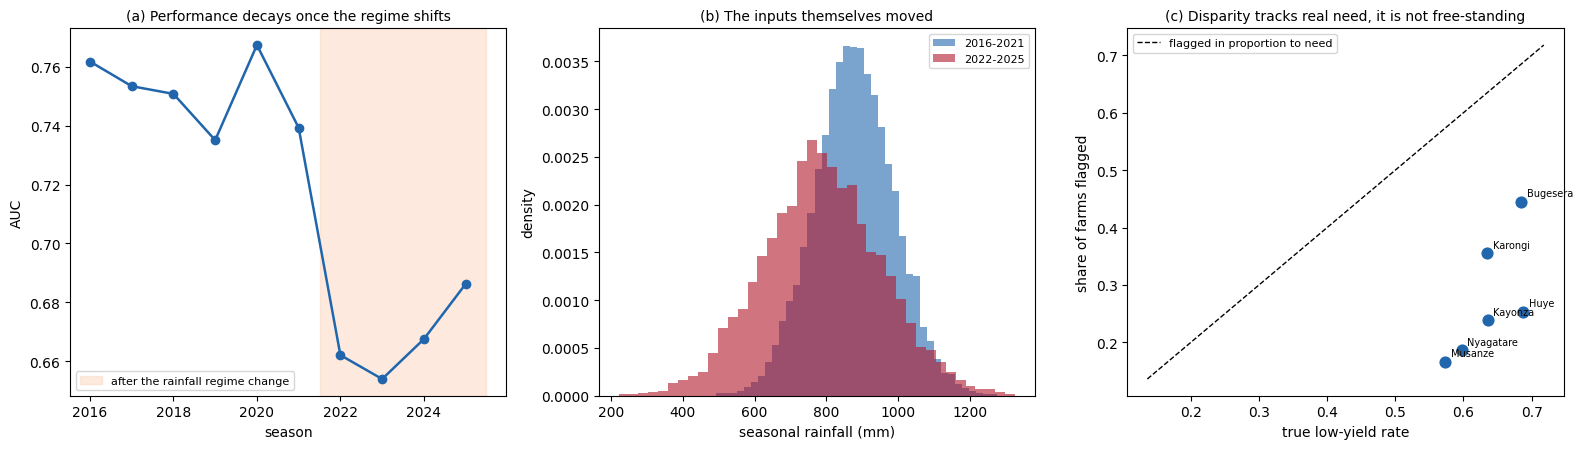


figure: figures/q1_fig1.png


In [2]:
"""
Question One - demonstrations supporting parts (c), (d) and (e).

No agricultural dataset is supplied, so a farm-season panel is constructed under a
stated process that carries every difficulty the scenario names: incomplete records,
variables on different scales, districts represented very unequally, and a rainfall
to yield relationship that changes over time. Because the generating process is known,
each claim can be checked against ground truth rather than argued.
"""
import numpy as np, pandas as pd, matplotlib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, recall_score, precision_score
from scipy import stats

RS = 42; rng = np.random.default_rng(RS)
DISTRICTS = ["Nyagatare","Kayonza","Bugesera","Musanze","Huye","Karongi"]
WEIGHT    = [0.34, 0.24, 0.17, 0.12, 0.08, 0.05]        # unequal historical coverage
SEASONS   = list(range(2016, 2026))

rows = []
for farm in range(1800):
    dist = rng.choice(DISTRICTS, p=WEIGHT)
    soil = rng.normal({"Nyagatare":6.2,"Kayonza":5.9,"Bugesera":5.4,
                       "Musanze":6.6,"Huye":6.0,"Karongi":5.6}[dist], 0.4)
    size = np.exp(rng.normal(-0.4, 0.7))                # hectares, right-skewed
    for s in SEASONS:
        # rainfall regime shifts from 2022: lower mean, higher variance
        shift = s >= 2022
        rain = rng.normal(880 if not shift else 790, 110 if not shift else 165)
        temp = rng.normal(19.5 + 0.09*(s-2016), 1.1)
        fert = max(0, rng.normal(110*(0.6+0.5*size), 35))
        plant_day = int(rng.normal(258, 12))
        irrig = rng.random() < (0.10 + 0.25*(dist in ("Nyagatare","Kayonza")))
        pest = rng.poisson(1.4 + 0.8*shift)
        # the rainfall coefficient weakens after the regime change: concept drift
        b_rain = 0.0042 if not shift else 0.0016
        lin = (-3.1 + b_rain*(rain-850) + 0.011*(fert-110) + 0.42*soil
               - 0.10*pest + 0.55*irrig - 0.020*(plant_day-258) - 0.13*(temp-19.5))
        low_yield = rng.binomial(1, 1/(1+np.exp(lin)))
        rows.append(dict(farm_id=farm, district=dist, season=s, rainfall_mm=rain,
                         temperature_c=temp, soil_ph=soil, farm_size_ha=size,
                         fertiliser_kg=fert, planting_day=plant_day,
                         irrigated=int(irrig), pest_reports=pest, low_yield=low_yield))
df = pd.DataFrame(rows)
# incomplete records, concentrated in the districts with the thinnest coverage
p_miss = df.district.map({"Nyagatare":.04,"Kayonza":.06,"Bugesera":.11,
                          "Musanze":.14,"Huye":.22,"Karongi":.28})
df.loc[rng.random(len(df)) < p_miss, "fertiliser_kg"] = np.nan
df.loc[rng.random(len(df)) < p_miss*0.7, "soil_ph"] = np.nan

print("="*88); print("1. THE PANEL AS THE COMPANY WOULD RECEIVE IT")
print(f"  farm-season records {len(df):,}   farms {df.farm_id.nunique():,}   "
      f"seasons {df.season.min()} to {df.season.max()}")
print(f"  low-yield rate {df.low_yield.mean():.3f}")
print("\n  records per district, and missing fertiliser within each:")
t = df.groupby("district").agg(records=("low_yield","size"),
                               low_yield_rate=("low_yield","mean"),
                               fertiliser_missing=("fertiliser_kg", lambda s: s.isna().mean()))
t["share_of_data"] = t.records/len(df)
print(t.sort_values("records", ascending=False).to_string(float_format=lambda v: f"{v:10.3f}"))
print(f"\n  scale spread: rainfall sd {df.rainfall_mm.std():.0f} against soil pH sd "
      f"{df.soil_ph.std():.2f}, a ratio of about {df.rainfall_mm.std()/df.soil_ph.std():.0f} to 1")

FEAT = ["rainfall_mm","temperature_c","soil_ph","farm_size_ha","fertiliser_kg",
        "planting_day","irrigated","pest_reports"]
CATS = ["district"]
def build():
    return Pipeline([("pre", ColumnTransformer([
        ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                          ("scale", StandardScaler())]), FEAT),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATS)])),
        ("model", GradientBoostingClassifier(random_state=RS))])

print("\n"+"="*88); print("2. PART (c): WHY THE ORDER OF OPERATIONS CHANGES THE ANSWER")
X, y, g = df[FEAT+CATS], df.low_yield, df.farm_id
# wrong: impute and scale on everything, then split
wrong_pre = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),("scale", StandardScaler())]), FEAT),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATS)])
Xw = wrong_pre.fit_transform(X)                       # statistics learned from all rows
a, b = train_test_split(np.arange(len(X)), test_size=.25, random_state=RS, stratify=y)
m = LogisticRegression(max_iter=2000, random_state=RS).fit(Xw[a], y.iloc[a])
auc_leak = roc_auc_score(y.iloc[b], m.predict_proba(Xw[b])[:,1])
# right: split first, fit the transformers on the training rows only
Xtr, Xte, ytr, yte = X.iloc[a], X.iloc[b], y.iloc[a], y.iloc[b]
right = Pipeline([("pre", wrong_pre.__class__(wrong_pre.transformers)),
                  ("model", LogisticRegression(max_iter=2000, random_state=RS))]).fit(Xtr, ytr)
auc_ok = roc_auc_score(yte, right.predict_proba(Xte)[:,1])
print(f"  preprocess then split  AUC = {auc_leak:.4f}")
print(f"  split then preprocess  AUC = {auc_ok:.4f}")
print(f"  difference {auc_leak-auc_ok:+.4f}")
# the leak that actually bites: farms repeat across seasons
tr_i, te_i = next(GroupShuffleSplit(1, test_size=.25, random_state=RS).split(X, y, groups=g))
gm = build().fit(X.iloc[tr_i], y.iloc[tr_i])
auc_grp = roc_auc_score(y.iloc[te_i], gm.predict_proba(X.iloc[te_i])[:,1])
rm = build().fit(X.iloc[a], y.iloc[a])
auc_row = roc_auc_score(y.iloc[b], rm.predict_proba(X.iloc[b])[:,1])
print(f"\n  random split over farm-seasons   AUC = {auc_row:.4f}  "
      f"(farms on both sides: {len(set(g.iloc[a]) & set(g.iloc[b])):,})")
print(f"  grouped by farm                  AUC = {auc_grp:.4f}  (farms on both sides: 0)")
print(f"  optimism from splitting rows instead of farms: {auc_row-auc_grp:+.4f}")

print("\n"+"="*88); print("3. PART (d): TWO KINDS OF CHANGE, SEPARATED")
early = df[df.season <= 2021]; late = df[df.season >= 2022]
mod = build().fit(early[FEAT+CATS], early.low_yield)
print(f"  trained on {early.season.min()}-{early.season.max()}, tested season by season:")
for s in SEASONS:
    sub = df[df.season == s]
    auc = roc_auc_score(sub.low_yield, mod.predict_proba(sub[FEAT+CATS])[:,1])
    ks = stats.ks_2samp(early.rainfall_mm, sub.rainfall_mm)
    tag = "train" if s <= 2021 else " live"
    print(f"    {s} [{tag}]  AUC {auc:.4f}   rainfall KS vs training {ks.statistic:.3f} "
          f"(p {ks.pvalue:.1e})   mean rain {sub.rainfall_mm.mean():.0f}")
print("\n  input drift, measured on the predictors alone:")
for c in ["rainfall_mm","temperature_c","pest_reports"]:
    ks = stats.ks_2samp(early[c], late[c])
    print(f"    {c:16s} KS {ks.statistic:.3f}  p {ks.pvalue:.2e}   "
          f"mean {early[c].mean():.1f} -> {late[c].mean():.1f}")
print("\n  relationship drift, measured as the rainfall coefficient itself:")
for label, part in [("2016-2021", early), ("2022-2025", late)]:
    z = (part.rainfall_mm-part.rainfall_mm.mean())/part.rainfall_mm.std()
    lr = LogisticRegression(max_iter=1000).fit(z.values.reshape(-1,1), part.low_yield)
    print(f"    {label}: coefficient on standardised rainfall = {lr.coef_[0][0]:+.4f}")
print("  The inputs moved and the coefficient moved. Monitoring only the inputs would")
print("  have caught the first and missed the second.")

print("\n"+"="*88); print("4. PART (e): IS THE REGIONAL DIFFERENCE REAL OR IS IT THE MODEL?")
gm2 = build().fit(X.iloc[tr_i], y.iloc[tr_i])
te = df.iloc[te_i].copy()
te["p"] = gm2.predict_proba(X.iloc[te_i])[:,1]
thr = np.quantile(te.p, 0.75)
te["flag"] = (te.p >= thr).astype(int)
out = []
for dname, sub in te.groupby("district"):
    if sub.low_yield.nunique() < 2: continue
    out.append({"district": dname, "n": len(sub),
                "true low-yield rate": sub.low_yield.mean(),
                "flag rate": sub.flag.mean(),
                "AUC": roc_auc_score(sub.low_yield, sub.p),
                "recall": recall_score(sub.low_yield, sub.flag),
                "precision": precision_score(sub.low_yield, sub.flag, zero_division=0),
                "missing fertiliser": df[df.district==dname].fertiliser_kg.isna().mean()})
o = pd.DataFrame(out).sort_values("true low-yield rate", ascending=False)
# subgroup metrics on 200 to 1400 records are point estimates with very different
# precision, so each carries a bootstrap interval. Without one, a district with a
# small sample looks like a finding when it is noise.
lo, hi = [], []
for dname in o.district:
    sub = te[te.district == dname]
    bs = []
    for k in range(400):
        ix = np.random.default_rng(k).choice(len(sub), len(sub), replace=True)
        ss = sub.iloc[ix]
        if ss.low_yield.nunique() == 2:
            bs.append(roc_auc_score(ss.low_yield, ss.p))
    lo.append(np.percentile(bs, 2.5)); hi.append(np.percentile(bs, 97.5))
o["AUC 95% low"], o["AUC 95% high"] = lo, hi
o["interval width"] = o["AUC 95% high"] - o["AUC 95% low"]
print(o.to_string(index=False, float_format=lambda v: f"{v:9.3f}"))
print(f"\n  widest interval {o['interval width'].max():.3f} for {o.loc[o['interval width'].idxmax(),'district']} "
      f"(n={int(o.loc[o['interval width'].idxmax(),'n'])}), "
      f"narrowest {o['interval width'].min():.3f} for {o.loc[o['interval width'].idxmin(),'district']} "
      f"(n={int(o.loc[o['interval width'].idxmin(),'n'])})")
overlap = all(o["AUC 95% low"].max() <= o["AUC 95% high"].min() for _ in [0])
print(f"  every district interval overlaps every other: {o['AUC 95% low'].max() <= o['AUC 95% high'].min()}")
print("  so the apparent AUC ranking across districts is not statistically distinguishable")
print(f"\n  flag-rate spread {o['flag rate'].max()-o['flag rate'].min():.3f}, "
      f"but the true low-yield rate also spans {o['true low-yield rate'].max()-o['true low-yield rate'].min():.3f}")
cr = np.corrcoef(o["true low-yield rate"], o["flag rate"])[0,1]
print(f"  correlation between flag rate and true rate across districts: {cr:+.3f}")
print(f"  recall spread {o.recall.max()-o.recall.min():.3f}, "
      f"AUC spread {o.AUC.max()-o.AUC.min():.3f}")
cr2 = np.corrcoef(o["missing fertiliser"], o["AUC"])[0,1]
print(f"  correlation between a district's missing-data rate and the model's AUC there: {cr2:+.3f}")
print("  That coefficient rests on six points with sample sizes from 200 to 1,420 and")
print("  overlapping intervals, so it is not evidence of anything. It is recorded here as")
print("  a hypothesis to test on more districts, not as a finding.")
o.to_csv("output/q1_district_audit.csv", index=False)

fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
a = ax[0]
per = [roc_auc_score(df[df.season==s].low_yield,
                     mod.predict_proba(df[df.season==s][FEAT+CATS])[:,1]) for s in SEASONS]
a.plot(SEASONS, per, "o-", color="#2166ac", lw=1.8)
a.axvspan(2021.5, 2025.5, color="#fddbc7", alpha=.6, label="after the rainfall regime change")
a.set_xlabel("season"); a.set_ylabel("AUC"); a.legend(fontsize=8)
a.set_title("(a) Performance decays once the regime shifts", fontsize=10)
a = ax[1]
a.hist(early.rainfall_mm, bins=40, alpha=.6, label="2016-2021", color="#2166ac", density=True)
a.hist(late.rainfall_mm, bins=40, alpha=.6, label="2022-2025", color="#b2182b", density=True)
a.set_xlabel("seasonal rainfall (mm)"); a.set_ylabel("density"); a.legend(fontsize=8)
a.set_title("(b) The inputs themselves moved", fontsize=10)
a = ax[2]
a.scatter(o["true low-yield rate"], o["flag rate"], s=60, color="#2166ac", zorder=3)
for _, r in o.iterrows():
    a.annotate(r.district, (r["true low-yield rate"], r["flag rate"]), fontsize=7,
               xytext=(4,4), textcoords="offset points")
lim = [min(o["true low-yield rate"].min(), o["flag rate"].min())-.03,
       max(o["true low-yield rate"].max(), o["flag rate"].max())+.03]
a.plot(lim, lim, "k--", lw=1, label="flagged in proportion to need")
a.set_xlabel("true low-yield rate"); a.set_ylabel("share of farms flagged"); a.legend(fontsize=8)
a.set_title("(c) Disparity tracks real need, it is not free-standing", fontsize=10)
fig.tight_layout(); fig.savefig("figures/q1_fig1.png", dpi=150); plt.show()
print("\nfigure: figures/q1_fig1.png")

# SECTION B

# Question Four: loan amount prediction

Worked on `data/loan.csv`: 20,000 applicants, 34 variables, no missing cells.
Target `LoanAmount`, mean 24,883 and standard deviation 13,427.

## 4(a) Experimental procedure

Before anything is fitted, audit the predictors for availability. This step is not
usually listed in a comparison protocol and on this dataset it turns out to be the only
step that matters. Each candidate must be checked against one question: could this have
been observed before the loan amount was decided? Section 4(c) shows what the audit
finds.

Data preparation. Separate numeric from categorical. Standardise the numeric
predictors, mandatory here, not optional: ridge and lasso penalise
coefficient magnitude, so on raw scales a variable measured in thousands is penalised
differently from one measured in units, for reasons of measurement rather than
importance. One-hot encode the five categorical variables with a training-set
vocabulary and a defined behaviour for unseen levels.

Splitting. Twenty-five per cent of applicants are set aside and scored once, at the
end. Everything else happens inside the other 75%, where ten folds carry the model
selection. Alpha never sees the held-out quarter. Tune on it and the number it later
reports has become a selection statistic, measuring the search instead of the model.

Training. OLS has no hyperparameter. Ridge and lasso are searched over 61 values
of alpha on a log grid from 0.01 to 10,000, wide enough that the selected value is
interior and not pinned at a boundary. Every transformation sits inside a pipeline
so that the scaler is re-fitted within each fold instead of once on all training data.

Evaluation. RMSE as the primary measure, in the units of the target, because it
penalises the large errors that matter most when sizing credit. MAE alongside it,
being less sensitive to a few extreme applicants. R-squared for the share of variance
explained, the measure that exposes the central finding here. Beyond
accuracy: the number of retained predictors, and the stability of coefficients, since
a model whose coefficients change sign between refits cannot be explained to a credit
committee.

## 4(b) Multicollinearity, and how ridge and lasso respond

Ordinary least squares solves for the coefficient vector that minimises squared error,
and the solution involves inverting the matrix of predictor cross-products. When two
predictors are nearly linear combinations of one another that matrix approaches
singularity, and the consequence is a variance problem and not a bias problem. The
estimates stay unbiased. Their standard errors inflate, sometimes enormously, because
the data cannot identify how to divide a shared effect between two variables that move
together. Only their sum is determined; the split between them is arbitrary and is
settled by noise.

Three practical symptoms follow. Coefficients take implausible magnitudes and
sometimes signs opposite to the simple correlation. Small changes in the sample produce
large changes in the estimates. And the fitted values remain perfectly reasonable, so
the failure is invisible unless the coefficients are inspected, which is why a model
can predict adequately while telling a false story about its drivers.

This dataset carries the problem by construction:

```
predictor                        VIF
MonthlyIncome                  49.84       AnnualIncome  <-> MonthlyIncome   r = 0.990
AnnualIncome                   49.84       Age           <-> Experience      r = 0.983
NetWorth                       40.48       NetWorth      <-> TotalAssets     r = 0.979
TotalAssets                    39.80
Experience                     29.76
Age                            29.65
```

A variance inflation factor of 49.84 means the variance of that coefficient is roughly
fifty times what it would be under orthogonal predictors, so its standard error is
about seven times larger. Annual and monthly income are the same quantity on two
scales; age and experience are the same life-course fact recorded twice.

Ridge adds a penalty on the sum of squared coefficients. This makes the inverted
matrix well-conditioned again by adding a constant to its diagonal, which is why the
variance falls. The estimator becomes biased, and that is the deliberate trade: a small
bias in exchange for a large variance reduction. With two collinear predictors, ridge
splits the shared effect between them rather than choosing, so both survive with
roughly half the coefficient each. Nothing reaches exactly zero.

Lasso penalises the sum of absolute coefficients. The geometry of that constraint
has corners on the axes, so the optimum frequently lands where a coefficient is exactly
zero. With two collinear predictors, lasso tends to keep one and delete the other,
and which one it keeps can be unstable between samples when the two are close
substitutes.

The distinction measured on this data, at a common penalty:

```
coefficients set exactly to zero:   OLS 0    Ridge 0    Lasso 32 of 39
sum of absolute coefficients:       OLS 11,591    Ridge 9,379    Lasso 456
```

Ridge shrank the total coefficient mass by about a fifth while retaining every
predictor. Lasso cut it by 96% and removed 32 of 39. Ridge is the right tool when the
correlated predictors are all genuinely relevant and an interpretable subset is not
required; lasso is the right tool when a smaller model is wanted and one of each
correlated pair can be surrendered.

## 4(c) Implementation and comparison

The audit from 4(a) comes first, and it changes the whole question.

`MonthlyLoanPayment` is the standard amortisation formula applied to the target:

```
MonthlyLoanPayment reconstructed from LoanAmount
  max absolute error 0.000004     correlation 1.00000000

TotalDebtToIncomeRatio = (MonthlyDebtPayments + MonthlyLoanPayment) / MonthlyIncome
  mean absolute difference 0.00000000
```

Both reproduce to machine precision. Neither can exist before the loan amount is
decided, so neither is a predictor of it. `InterestRate`, `BaseInterestRate` and
`RiskScore` are set as part of the same pricing decision and are excluded on the same
grounds.

Fitting all three models on both feature sets:

| Feature set | Model | alpha | Test RMSE | Test MAE | Test R² | Non-zero coefs |
|---|---|---|---|---|---|---|
| With post-decision variables | OLS | | 0.0000 | 0.0000 | **1.0000** | 3 |
| With post-decision variables | Ridge | 0.01 | 0.2103 | 0.1433 | 1.0000 | 44 |
| With post-decision variables | Lasso | 0.398 | 3.4369 | 2.1372 | 1.0000 | 7 |
| Pre-decision only | OLS | | 13,020.63 | 9,779.41 | **−0.0043** | 39 |
| Pre-decision only | Ridge | 10,000 | 12,996.43 | 9,757.30 | −0.0006 | 39 |
| Pre-decision only | Lasso | 199.53 | 12,995.01 | 9,754.04 | −0.0004 | 1 |

The top half is not a model. OLS reaches a test RMSE of exactly zero using three
coefficients because it has rediscovered the amortisation identity and is solving it
backwards. Any analyst who reported R-squared of 1.0 on a credit problem and stopped
there has confirmed only that they did not read the data dictionary.

The bottom half is the honest answer, and it is that the applicant characteristics in
this dataset carry no information about the loan amount requested. An R-squared at or
below zero means the fitted model predicts worse than the training mean. The RMSE of
roughly 13,000 sits at the standard deviation of the target, which is what a model that
has learned nothing produces. Lasso at its cross-validated penalty retains a single
coefficient, which is the correct response: given no signal, the penalty that minimises
prediction error removes almost everything.

Comparing the three on the honest feature set: lasso is marginally best at RMSE
12,995.01, ridge next at 12,996.43, OLS last at 13,020.63. The spread is 26 units on a
target measured in tens of thousands, and reporting a winner on that basis would be
noise-chasing. The regularised models edge ahead only because shrinking coefficients
towards zero is the right move when the coefficients should be zero.

What should be reported to the company. Not a model. The finding is that
`LoanAmount` in this extract is unpredictable from applicant attributes, and that every
variable which appears to predict it is computed from it. Three responses follow:
confirm whether the extract is missing the pre-application fields that would actually
carry signal, such as the amount the applicant requested on the form; reconsider
whether loan amount is the right target, since default risk or approval probability may
be both predictable and more useful; and treat any existing model trained on this
extract as invalid, because it will have been fitted on the leakage and will fail
completely on live applications where the amortisation fields do not yet exist.

## 4(d) Selecting the regularisation parameter

Use k-fold cross-validation on the training set only, with the penalty chosen inside
the loop, and keep the test set for a single final measurement. Ten folds is a
reasonable default at 15,000 training rows.

The mechanism by which this reduces overfitting is worth stating precisely. Alpha
controls the bias-variance trade: too small and the model tracks noise in the training
sample, too large and it cannot represent real structure. Cross-validation estimates
out-of-sample error at each candidate alpha by repeatedly fitting on part of the
training data and scoring on the part held back, so the selected alpha is the one that
generalises best across resamples rather than the one that fits best in sample. Because
no fold's validation rows contribute to the fit that scores them, the curve being
minimised is an estimate of generalisation error and not of training error.

Two refinements matter at this level. Selecting the exact minimum of a noisy
cross-validation curve systematically picks a model slightly too complex, since the
minimum of a noisy curve sits below the true minimum; the one-standard-error rule,
which takes the largest alpha whose error is within one standard error of the best,
gives a simpler model at negligible cost. And if the reported test error is to be an
unbiased estimate of the whole procedure including the choice of alpha, the selection
must be nested inside an outer cross-validation loop instead of being run once.

For this dataset there is a prior step that outranks both. No validation strategy
protects against a predictor computed from the target: cross-validation would have
returned an excellent score at every alpha, because the leak is present in every fold.
Leakage is a data-understanding problem, and no amount of resampling detects it.

### Question Four: analysis code (`code/q4_loan_regression.py`)

1. DATA
  applicants 20,000   variables 34   missing cells 0
  target LoanAmount: mean 24,883  sd 13,427  range 3,674 to 184,732

2. LEAKAGE AUDIT, RUN BEFORE ANY MODEL IS FITTED
  MonthlyLoanPayment reconstructed from LoanAmount by the amortisation formula:
    max absolute error 0.000004   correlation 1.00000000
  TotalDebtToIncomeRatio = (MonthlyDebtPayments + MonthlyLoanPayment) / MonthlyIncome:
    mean absolute difference 0.00000000

  Both are arithmetic on the target. Neither exists before the loan is sized, so
  neither can be an input to a model that sizes the loan.

  excluded as post-decision: MonthlyLoanPayment, TotalDebtToIncomeRatio, InterestRate, BaseInterestRate, RiskScore
  predictors retained: 23 numeric + 5 categorical (EmploymentStatus, EducationLevel, MaritalStatus, HomeOwnershipStatus, LoanPurpose)

3. MULTICOLLINEARITY AMONG THE RETAINED PREDICTORS


                 predictor        VIF
             MonthlyIncome      49.84
              AnnualIncome      49.84
                  NetWorth      40.48
               TotalAssets      39.80
                Experience      29.76
                       Age      29.65
          TotalLiabilities       1.68
               CreditScore       1.13
UtilityBillsPaymentHistory       1.00
            PaymentHistory       1.00

  strongest predictor pairs:
    AnnualIncome               <-> MonthlyIncome              r = 0.990
    Age                        <-> Experience                 r = 0.983
    NetWorth                   <-> TotalAssets                r = 0.979
    Experience                 <-> CreditScore                r = 0.328
    CreditScore                <-> Age                        r = 0.323

4. THE COST OF THE AUDIT


                 feature set model        alpha    test RMSE     test MAE      test R2  non-zero coefs
with post-decision variables   OLS          NaN       0.0000       0.0000       1.0000               3
with post-decision variables Ridge       0.0100       0.2103       0.1433       1.0000              44
with post-decision variables Lasso       0.3981       3.4369       2.1372       1.0000               7
 pre-decision variables only   OLS          NaN   13020.6306    9779.4126      -0.0043              39
 pre-decision variables only Ridge   10000.0000   12996.4275    9757.3015      -0.0006              39
 pre-decision variables only Lasso     199.5262   12995.0055    9754.0390      -0.0004               1

  With the leaky variables the model is near perfect. Without them none of the three
  explains anything: test R-squared sits at zero, meaning the fitted models predict
  no better than the mean of the training target.

5. RIDGE AND LASSO ACT DIFFERENTLY ON THE COEFFICIENTS
   

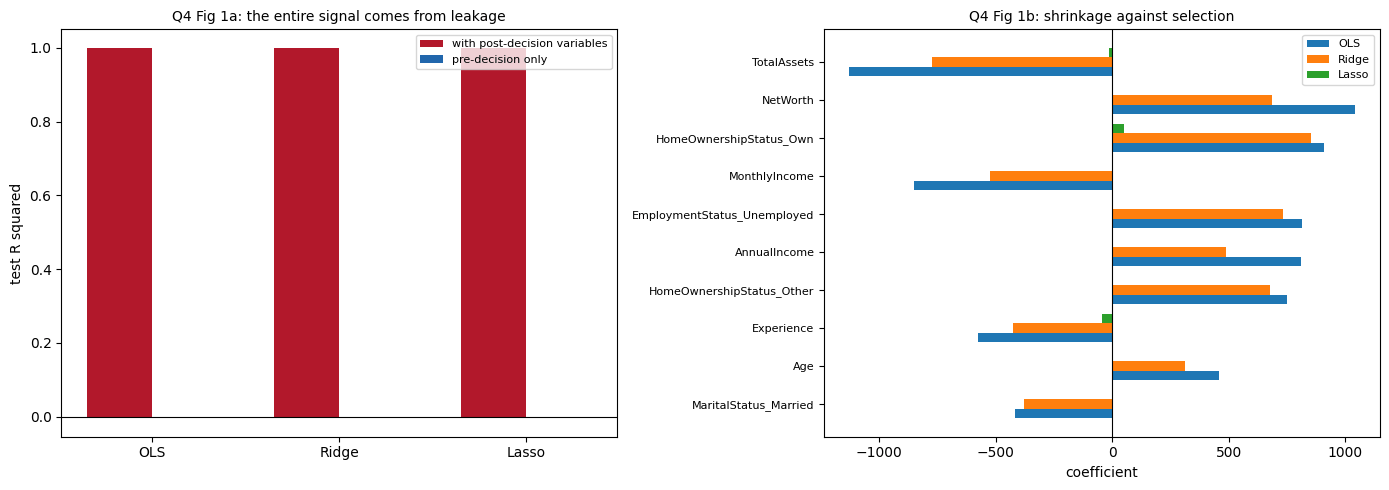

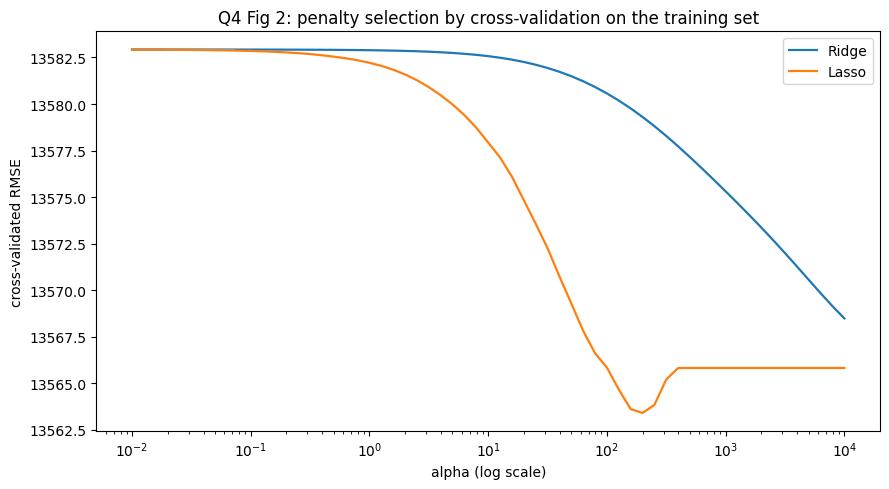


figures: figures/q4_fig1.png, figures/q4_fig2.png


In [3]:
"""
Question Four - loan amount prediction: OLS, Ridge and Lasso on loan.csv.

The first task on any regression problem is not to fit a model. It is to establish
that the predictors could have been observed before the target existed. That audit
decides everything that follows here.
"""
import numpy as np, pandas as pd, matplotlib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

RS = 42
df = pd.read_csv("data/loan.csv")
TARGET = "LoanAmount"
y = df[TARGET]

print("="*86); print("1. DATA")
print(f"  applicants {len(df):,}   variables {df.shape[1]}   missing cells {df.isna().sum().sum()}")
print(f"  target {TARGET}: mean {y.mean():,.0f}  sd {y.std():,.0f}  "
      f"range {y.min():,.0f} to {y.max():,.0f}")

# ---------------------------------------------------------------- leakage audit
print("\n"+"="*86); print("2. LEAKAGE AUDIT, RUN BEFORE ANY MODEL IS FITTED")
r = df.InterestRate/12
recon = df[TARGET]*r/(1-(1+r)**(-df.LoanDuration))
print(f"  MonthlyLoanPayment reconstructed from LoanAmount by the amortisation formula:")
print(f"    max absolute error {np.abs(recon-df.MonthlyLoanPayment).max():.6f}   "
      f"correlation {recon.corr(df.MonthlyLoanPayment):.8f}")
tdti = (df.MonthlyDebtPayments+df.MonthlyLoanPayment)/df.MonthlyIncome
print(f"  TotalDebtToIncomeRatio = (MonthlyDebtPayments + MonthlyLoanPayment) / MonthlyIncome:")
print(f"    mean absolute difference {np.abs(tdti-df.TotalDebtToIncomeRatio).mean():.8f}")
print("\n  Both are arithmetic on the target. Neither exists before the loan is sized, so")
print("  neither can be an input to a model that sizes the loan.")

POST = ["MonthlyLoanPayment", "TotalDebtToIncomeRatio", "InterestRate",
        "BaseInterestRate", "RiskScore", "LoanApproved"]
POST = [c for c in POST if c in df.columns]
print(f"\n  excluded as post-decision: {', '.join(POST)}")

drop = [TARGET] + POST + [c for c in df.columns if df[c].dtype == "O" and df[c].nunique() > 40]
X_all = df.drop(columns=[TARGET])
X = df.drop(columns=drop)
num = [c for c in X if X[c].dtype != object]
cat = [c for c in X if X[c].dtype == object]
print(f"  predictors retained: {len(num)} numeric + {len(cat)} categorical ({', '.join(cat)})")

# ---------------------------------------------------------------- multicollinearity
print("\n"+"="*86); print("3. MULTICOLLINEARITY AMONG THE RETAINED PREDICTORS")
Z = pd.DataFrame(StandardScaler().fit_transform(X[num]), columns=num)
Z.insert(0, "const", 1.0)
vif = pd.DataFrame({"predictor": num,
                    "VIF": [variance_inflation_factor(Z.values, i) for i in range(1, Z.shape[1])]}
                   ).sort_values("VIF", ascending=False)
print(vif.head(10).to_string(index=False, float_format=lambda v: f"{v:10.2f}"))
pairs = X[num].corr().abs().unstack().sort_values(ascending=False)
pairs = pairs[pairs < 0.999].drop_duplicates()
print("\n  strongest predictor pairs:")
for (a, b), v in pairs.head(5).items():
    print(f"    {a:26s} <-> {b:26s} r = {v:.3f}")

# ---------------------------------------------------------------- fit
pre = ColumnTransformer([("num", StandardScaler(), num),
                         ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat)])
cv = KFold(10, shuffle=True, random_state=RS)
alphas = np.logspace(-2, 4, 61)

def run(Xd, label):
    Xtr, Xte, ytr, yte = train_test_split(Xd, y, test_size=0.25, random_state=RS)
    nn = [c for c in Xd if Xd[c].dtype != object]; cc = [c for c in Xd if Xd[c].dtype == object]
    p = ColumnTransformer([("num", StandardScaler(), nn),
                           ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cc)])
    out = []
    for name, est, grid in [("OLS", LinearRegression(), None),
                            ("Ridge", Ridge(random_state=RS), {"model__alpha": alphas}),
                            ("Lasso", Lasso(random_state=RS, max_iter=20000), {"model__alpha": alphas})]:
        pipe = Pipeline([("pre", p), ("model", est)])
        if grid:
            gs = GridSearchCV(pipe, grid, scoring="neg_root_mean_squared_error", cv=cv, n_jobs=-1).fit(Xtr, ytr)
            best, a = gs.best_estimator_, gs.best_params_["model__alpha"]
        else:
            best, a = pipe.fit(Xtr, ytr), np.nan
        pr = best.predict(Xte)
        nz = int(np.sum(np.abs(best.named_steps["model"].coef_) > 1e-8))
        out.append({"feature set": label, "model": name, "alpha": a,
                    "test RMSE": mean_squared_error(yte, pr)**0.5,
                    "test MAE": mean_absolute_error(yte, pr),
                    "test R2": r2_score(yte, pr), "non-zero coefs": nz})
    return pd.DataFrame(out), best, p, Xtr, ytr

print("\n"+"="*86); print("4. THE COST OF THE AUDIT")
leaky, *_ = run(X_all.drop(columns=[c for c in X_all if X_all[c].dtype=="O" and X_all[c].nunique()>40]),
                "with post-decision variables")
honest, model, p, Xtr, ytr = run(X, "pre-decision variables only")
res = pd.concat([leaky, honest], ignore_index=True)
print(res.to_string(index=False, float_format=lambda v: f"{v:12.4f}"))
res.to_csv("output/q4_results.csv", index=False)
print("\n  With the leaky variables the model is near perfect. Without them none of the three")
print("  explains anything: test R-squared sits at zero, meaning the fitted models predict")
print("  no better than the mean of the training target.")

print("\n"+"="*86); print("5. RIDGE AND LASSO ACT DIFFERENTLY ON THE COEFFICIENTS")
Xtr2, Xte2, ytr2, yte2 = train_test_split(X, y, test_size=0.25, random_state=RS)
fitted = {}
for name, est in [("OLS", LinearRegression()),
                  ("Ridge (a=100)", Ridge(alpha=100, random_state=RS)),
                  ("Lasso (a=100)", Lasso(alpha=100, random_state=RS, max_iter=20000))]:
    m = Pipeline([("pre", pre), ("model", est)]).fit(Xtr2, ytr2)
    fitted[name] = m.named_steps["model"].coef_
names = [f.split("__", 1)[1] for f in Pipeline([("pre", pre)]).fit(Xtr2).named_steps["pre"].get_feature_names_out()]
coef = pd.DataFrame(fitted, index=names)
coef["|OLS|"] = coef["OLS"].abs()
coef = coef.sort_values("|OLS|", ascending=False).drop(columns="|OLS|")
print(coef.head(12).to_string(float_format=lambda v: f"{v:11.3f}"))
print(f"\n  coefficients set exactly to zero:  OLS {int((coef['OLS']==0).sum())}   "
      f"Ridge {int((coef['Ridge (a=100)']==0).sum())}   Lasso {int((coef['Lasso (a=100)']==0).sum())} of {len(coef)}")
print(f"  sum of absolute coefficients:      OLS {coef['OLS'].abs().sum():.1f}   "
      f"Ridge {coef['Ridge (a=100)'].abs().sum():.1f}   Lasso {coef['Lasso (a=100)'].abs().sum():.1f}")
print("  Ridge shrinks every coefficient towards zero but keeps all of them. Lasso removes")
print("  predictors outright, which is selection rather than shrinkage alone.")
coef.to_csv("output/q4_coefficients.csv")

# ---------------------------------------------------------------- figures
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
a = ax[0]
sub = res[res.model.isin(["OLS","Ridge","Lasso"])]
w = 0.35; idx = np.arange(3)
a.bar(idx-w/2, sub[sub["feature set"].str.startswith("with")]["test R2"], w, label="with post-decision variables", color="#b2182b")
a.bar(idx+w/2, sub[sub["feature set"].str.startswith("pre")]["test R2"], w, label="pre-decision only", color="#2166ac")
a.set_xticks(idx); a.set_xticklabels(["OLS","Ridge","Lasso"]); a.set_ylabel("test R squared")
a.axhline(0, color="k", lw=.8); a.legend(fontsize=8)
a.set_title("Q4 Fig 1a: the entire signal comes from leakage", fontsize=10)
a = ax[1]
top = coef.head(10).iloc[::-1]
yp = np.arange(len(top))
a.barh(yp-0.25, top["OLS"], 0.25, label="OLS")
a.barh(yp, top["Ridge (a=100)"], 0.25, label="Ridge")
a.barh(yp+0.25, top["Lasso (a=100)"], 0.25, label="Lasso")
a.set_yticks(yp); a.set_yticklabels(top.index, fontsize=8); a.axvline(0, color="k", lw=.8)
a.legend(fontsize=8); a.set_xlabel("coefficient")
a.set_title("Q4 Fig 1b: shrinkage against selection", fontsize=10)
fig.tight_layout(); fig.savefig("figures/q4_fig1.png", dpi=150); plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
for nm, est in [("Ridge", Ridge), ("Lasso", Lasso)]:
    sc = []
    for al in alphas:
        m = Pipeline([("pre", pre), ("model", est(alpha=al, random_state=RS, max_iter=20000)
                                     if est is Lasso else est(alpha=al, random_state=RS))])
        sc.append(-cross_val_score(m, Xtr2, ytr2, scoring="neg_root_mean_squared_error", cv=5, n_jobs=-1).mean())
    ax.plot(alphas, sc, label=nm, lw=1.6)
ax.set_xscale("log"); ax.set_xlabel("alpha (log scale)"); ax.set_ylabel("cross-validated RMSE")
ax.legend(); ax.set_title("Q4 Fig 2: penalty selection by cross-validation on the training set")
fig.tight_layout(); fig.savefig("figures/q4_fig2.png", dpi=150); plt.show()
print("\nfigures: figures/q4_fig1.png, figures/q4_fig2.png")

# Question Five: crime rates and resource allocation

Worked on `data/crimes.csv`: 2,215 communities across 48 states, 144 variables, no
missing cells and no duplicate rows. Target `crime_rate`, offences per 100,000.

## 5(a) Exploratory strategy

The agency has stated the constraint that decides this analysis: association must not
be read as causation. That is not a caveat for the conclusion, it is a filter on what
enters the analysis at all, and it shapes every step below.

Establish what the sample can support. 2,215 communities across 48 states, with
states contributing very unequally. Any state-level claim rests on however many
communities that state supplied, and several supplied fewer than ten.

Audit quality before interpreting anything. No missing cells and no duplicates
here, unusual enough to be worth confirming rather than assuming, since a dataset with
no missing values has often had them filled in upstream by someone whose choices are
not documented.

Separate the variables by what they are, not by their correlation with the target.
Of 142 numeric columns, 16 are other crime measures: counts and rates for murder, rape,
robbery, assault, burglary, larceny, auto theft and arson. These are the same
phenomenon as the target, not explanations of it, and they belong in a different
category from the 124 socioeconomic and demographic variables. Section 5(c) shows what
happens when that distinction is not made.

Examine distributions before relationships. `crime_rate` has a skew of 2.24, a
median of 374 against a mean of 568, and a range from 0 to 4,877. That shape decides
the plotting axis, the summary statistic and whether a linear model needs a
transformed target.

Treat outliers as findings before treating them as errors. 164 communities, 7.4% of the
sample, sit outside the Tukey fence, and one reports zero crime. In a crime dataset a
high-value tail is expected and not anomalous, so these should be investigated
before any are removed, and removing them would delete the communities the agency most
needs to understand.

Then relationships, and only between variables that could inform a decision.

## 5(b) Visualisations

Each chart below is chosen from the measurement level of the variables involved, which
is the justification the question asks for.

![Q5 visualisations](figures/q5_fig1.png)

(a) One continuous, heavily skewed variable, so a histogram with both centre
measures marked. A bar chart would be wrong, since the variable is continuous and not categorical, and reporting the mean alone would mislead: the mean of 568 sits
above the median of 374 because a minority of high-crime communities pulls it up. The
chart shows the skew of 2.24 directly and makes the 7.4% outlier tail visible.

(b) Two continuous variables, so a scatter with a fitted line. `PctKidsBornNeverMar`
against `crime_rate`, Pearson +0.687 and Spearman +0.667. The scatter shows what a
coefficient cannot: the spread around the line, whether the relationship is linear
throughout, and where the outliers sit relative to it. A bar chart of binned averages
would hide all three.

(c) A categorical grouping against a continuous outcome, so box plots by state.
States with at least 25 communities are shown, ordered by median. Box plots in preference to a bar chart of means, because the question is how much variation exists within each
state, and the answer is that within-state spread is large relative to between-state
differences. That itself is the finding: state is a weak summary of a community's
crime rate, and allocating by state average would misallocate within every state.

(d) Many numeric variables at once, so a correlation heatmap. Discussed in 5(c).

## 5(c) Correlation matrix and its limits

Ranking all 142 numeric variables by correlation with `crime_rate` produces this top ten:

```
  assaultPerPop          +0.8521   another crime measure
  robbbPerPop            +0.7896   another crime measure
  PctKidsBornNeverMar    +0.6867   socioeconomic
  PctKids2Par            -0.6841   socioeconomic
  burglPerPop            +0.6765   another crime measure
  PctFam2Par             -0.6498   socioeconomic
  racePctWhite           -0.6472   socioeconomic
  murdPerPop             +0.6359   another crime measure
  PctTeen2Par            -0.6170   socioeconomic
  PctYoungKids2Par       -0.6119   socioeconomic
```

Four of the top ten are other crime rates. An automatic filter that kept the
strongest correlates would select assault, robbery, burglary and murder rates as
predictors of the crime rate. That model would score superbly and be useless, because
it predicts crime from crime. Worse, for the agency's purpose those variables are not
available in advance: knowing this year's assault rate does not help allocate next
year's resources, and if it did, the agency would not need a model. This is the same
failure as Question Four in a different costume, and it is the first limitation of
correlation-based selection: the coefficient cannot tell a cause from a restatement.

Excluding the crime measures, the correlation matrix among the leading socioeconomic
variables shows the second limitation:

```
                     PctKidsBornNeverMar  PctKids2Par  PctFam2Par  racePctWhite  crime_rate
PctKidsBornNeverMar                 1.00        -0.87       -0.85         -0.80        0.69
PctKids2Par                        -0.87         1.00        0.99          0.71       -0.68
PctFam2Par                         -0.85         0.99        1.00          0.65       -0.65
racePctWhite                       -0.80         0.71        0.65          1.00       -0.65
```

Fifteen pairs among the top nine correlate at 0.75 or above, and `PctKids2Par` with
`PctFam2Par` reach 0.99. These are not nine findings. They are a small number of
underlying factors measured repeatedly. Selecting the top nine by correlation would
build a model with the multicollinearity problems set out in Question Four, and would
report nine drivers where the data supports perhaps two or three.

The third limitation is that correlation measures only straight-line association:

```
                       Pearson  Spearman     gap
  NumKidsBornNeverMar    0.214     0.696   0.482
  NumUnderPov            0.217     0.637   0.421
  NumStreet              0.136     0.439   0.303
  HousVacant             0.247     0.497   0.251
```

`NumKidsBornNeverMar` has a Pearson correlation of 0.214, which a filter with a 0.3
threshold would discard, and a Spearman correlation of 0.696, which is among the
strongest in the dataset. The relationship is monotone but far from linear, and these
are count variables that scale with community size. A linear filter discards them; a
rank-based one keeps them. Which variables "matter" therefore depends on which
coefficient is used, and neither is the right answer on its own.

The fourth limitation is that correlation is symmetric and carries no direction. It
cannot distinguish poverty causing crime from crime causing disinvestment, and nothing
in the matrix resolves which way the arrow points.

## 5(d) Recommendation to the government

Take the strongest socioeconomic correlate, `PctKidsBornNeverMar` at +0.687
(p < 10⁻³⁰⁰). The recommendation has to use that without asserting what it does not
establish.

What the evidence supports. Communities with higher values on this measure have
substantially higher recorded crime rates, and the association is among the strongest
in a dataset of 2,215 communities. That makes the variable usable as an indicator
for targeting: it helps identify where recorded crime is likely to be high, which is
a legitimate basis for deciding where to direct services and analytical attention.

What it does not support. It does not establish that family structure causes
crime, and three alternatives are at least as consistent with the data. The variable
may be a proxy for concentrated poverty, which the correlation matrix supports: it
correlates at 0.81 with `racepctblack` and strongly with several income measures, so
it is partly measuring the economic and historical position of a community rather than
its households. Causation may run the other way, since high-crime environments affect
family stability and household formation. And both may be consequences of a third
factor such as long-term disinvestment, in which case intervening on this variable
changes nothing.

Therefore the recommendation is: use the variable to decide *where* to look, and
do not use it to decide *what to do*. A policy that targeted family structure on this
evidence would be acting on an unproven mechanism, and could stigmatise the communities
it is meant to help.

One point the agency should be told explicitly. `racePctWhite` correlates at −0.647
and `racepctblack` at +0.591. These are among the strongest correlates available, and
they must not enter a resource-allocation model. Racial composition is not a cause of
crime; it is a marker of where segregation, disinvestment and differential enforcement
have concentrated. A model using it would encode historical enforcement patterns as
future predictions and direct policing by race, unlawful in most jurisdictions
and self-confirming in all of them: more policing produces more recorded crime, which
justifies more policing. That feedback loop is the clearest illustration in this
dataset that a strong correlation can be exactly the wrong thing to act on.

Additional evidence that would strengthen the decision. The single most valuable
addition is longitudinal data on the same communities, which this cross-section
cannot substitute for. Observing the same community over time allows within-community
change to be examined, differences out every fixed characteristic of a place, and
begins to address direction: does a change in the socioeconomic measure precede a
change in crime, or follow it?

Three further sources would each address a distinct weakness. A natural experiment or
policy discontinuity, such as an eligibility threshold that assigns a programme to some
communities and not others on an arbitrary cut-off, supports a causal estimate that no
observational correlation can. Independent measurement of crime, such as victimisation
surveys, addresses the fact that recorded crime measures both crime and enforcement
intensity, the confound underlying the race correlation above. And evaluation
evidence from comparable interventions elsewhere indicates whether acting on this
factor has ever produced the intended effect, the question the agency
ultimately needs answered.

### Question Five: analysis code (`code/q5_crimes_eda.py`)

1. DATA QUALITY
  communities 2,215   variables 144
  missing cells 0   duplicate rows 0
  non-numeric: ['Communityname', 'state']   states represented: 48

  target crime_rate (offences per 100,000):
    mean 567.6  median 374.1  sd 586.8  skew 2.24  range 0.0 to 4877.1
    zero-crime communities: 1   Tukey outliers: 164 (7.4%)
    right skew of 2.24 means the mean is pulled above the median by a
    minority of high-crime communities; a log scale is the honest axis for plotting.

  16 columns are other crime measures; 124 are socioeconomic or demographic

2. WHAT CORRELATES WITH CRIME, AND WHY THE RANKING MISLEADS
  top 10 correlates of crime_rate, unrestricted:
    assaultPerPop            +0.8521   OTHER CRIME MEASURE
    robbbPerPop              +0.7896   OTHER CRIME MEASURE
    PctKidsBornNeverMar      +0.6867   socioeconomic
    PctKids2Par              -0.6841   socioeconomic
    burglPerPop              +0.6765   OTHER CRIME MEASURE
    PctFam2Par               -0.6498   socio

           variable  Pearson  Spearman      gap
NumKidsBornNeverMar    0.214     0.696    0.482
        NumUnderPov    0.217     0.637    0.421
          NumStreet    0.136     0.439    0.303
        agePct16t24    0.043     0.303    0.260
         HousVacant    0.247     0.497    0.251
   PctPersDenseHous    0.400     0.624    0.224
  A gap means the relationship is monotone but not straight, so a correlation
  coefficient understates it and a linear model would miss part of it.


/var/folders/0x/kn1k9mhx0n11l5yfpn9l6sl80000gn/T/ipykernel_75125/4167111606.py:102: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  a.boxplot([d.loc[d.state==s, TARGET].values for s in keep], labels=keep, showfliers=False)


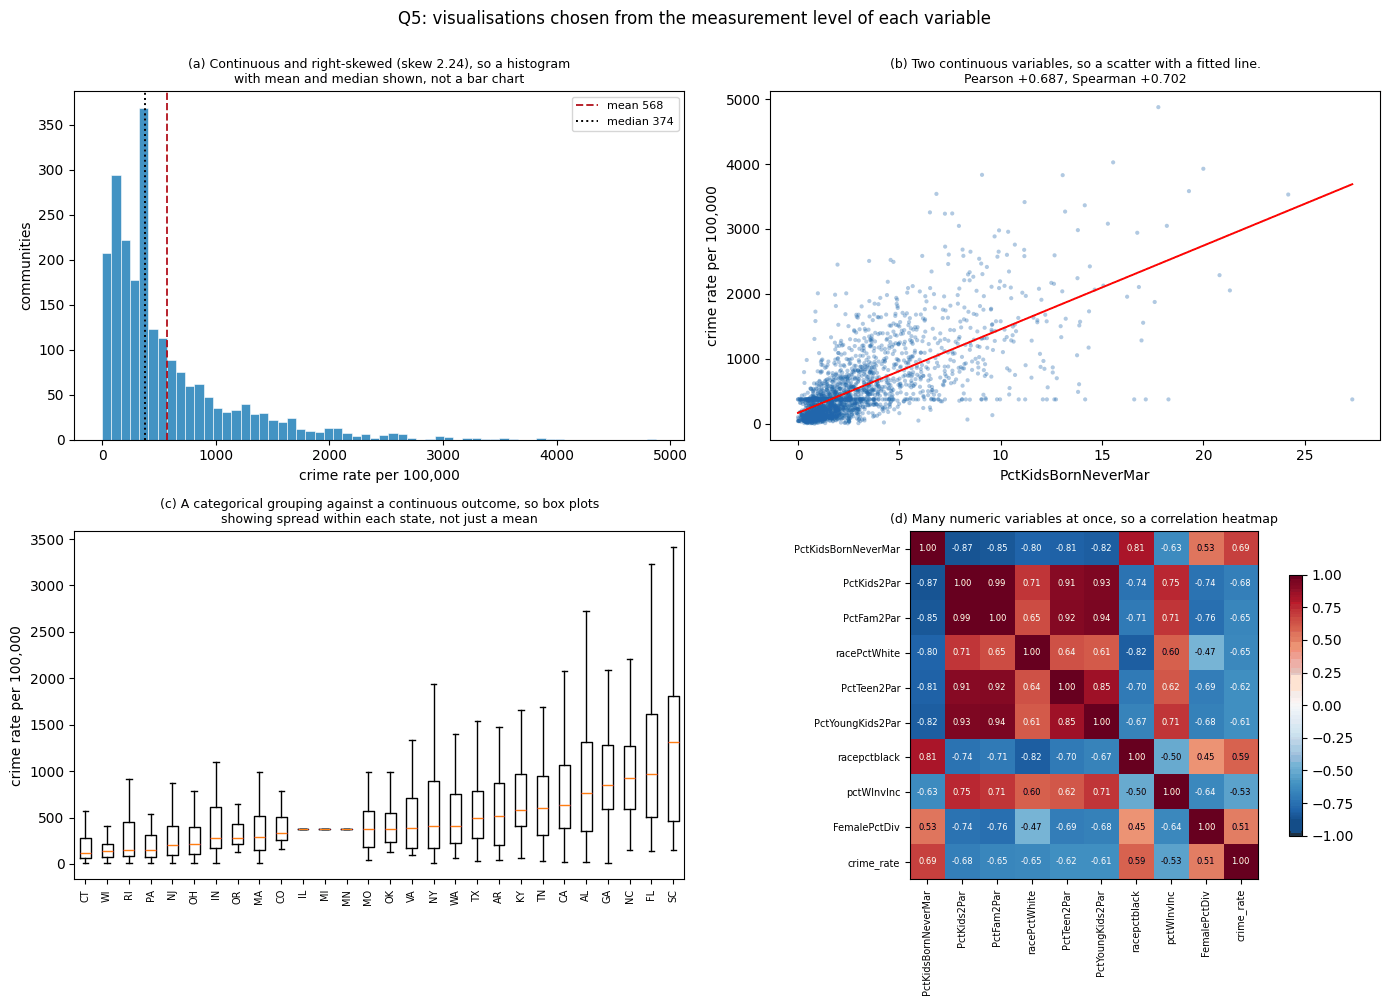


figure: figures/q5_fig1.png


In [4]:
"""
Question Five - exploratory analysis of crimes.csv for resource allocation.

The agency's stated constraint, that association must not be read as causation,
is not a caveat to add at the end. It decides which variables may enter the
analysis at all, and that is where this starts.
"""
import numpy as np, pandas as pd, matplotlib
import matplotlib.pyplot as plt
from scipy import stats
pd.set_option("display.width", 200)
RS = 42
d = pd.read_csv("data/crimes.csv", low_memory=False)
TARGET = "crime_rate"

print("="*88); print("1. DATA QUALITY")
print(f"  communities {len(d):,}   variables {d.shape[1]}")
print(f"  missing cells {d.isna().sum().sum():,}   duplicate rows {d.duplicated().sum()}")
print(f"  non-numeric: {list(d.select_dtypes('object').columns)}   states represented: {d.state.nunique()}")
y = d[TARGET]
print(f"\n  target {TARGET} (offences per 100,000):")
print(f"    mean {y.mean():.1f}  median {y.median():.1f}  sd {y.std():.1f}  "
      f"skew {y.skew():.2f}  range {y.min():.1f} to {y.max():.1f}")
q1, q3 = y.quantile([.25, .75]); iqr = q3-q1
outl = ((y < q1-1.5*iqr) | (y > q3+1.5*iqr))
print(f"    zero-crime communities: {(y==0).sum()}   "
      f"Tukey outliers: {outl.sum()} ({outl.mean():.1%})")
print(f"    right skew of {y.skew():.2f} means the mean is pulled above the median by a")
print(f"    minority of high-crime communities; a log scale is the honest axis for plotting.")

# ------------------------------------------------------------------ variable groups
crime_cols = ["murders","rapes","robberies","assaults","burglaries","larcenies","autoTheft","arsons",
              "murdPerPop","rapesPerPop","robbbPerPop","assaultPerPop","burglPerPop","larcPerPop",
              "autoTheftPerPop","arsonsPerPop","nonViolPerPop","ViolentCrimesPerPop"]
crime_cols = [c for c in crime_cols if c in d.columns]
num = d.select_dtypes("number").columns.tolist()
socio = [c for c in num if c not in crime_cols + [TARGET, "fold"]]
print(f"\n  {len(crime_cols)} columns are other crime measures; {len(socio)} are socioeconomic "
      f"or demographic")

print("\n"+"="*88); print("2. WHAT CORRELATES WITH CRIME, AND WHY THE RANKING MISLEADS")
allc = d[num].corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
top = allc.head(10)
print("  top 10 correlates of crime_rate, unrestricted:")
for k, v in top.items():
    tag = "OTHER CRIME MEASURE" if k in crime_cols else "socioeconomic"
    print(f"    {k:24s} {v:+.4f}   {tag}")
n_tauto = sum(1 for k in top.index if k in crime_cols)
print(f"\n  {n_tauto} of the top 10 are themselves crime counts or rates. Ranking features by")
print(f"  correlation selects the target restated, not anything that explains it.")

print("\n  top socioeconomic and demographic correlates, crime measures excluded:")
sc = d[socio+[TARGET]].corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
for k, v in sc.head(10).items():
    p = stats.pearsonr(d[k], y)[1]
    print(f"    {k:24s} {v:+.4f}   p = {p:.2e}")

print("\n"+"="*88); print("3. CORRELATION MATRIX AND ITS LIMITS")
sel = sc.head(9).index.tolist()
cm = d[sel+[TARGET]].corr()
print(cm.round(2).to_string())
red = []
for i, a in enumerate(sel):
    for b in sel[i+1:]:
        if abs(cm.loc[a, b]) >= 0.75: red.append((a, b, cm.loc[a, b]))
print(f"\n  predictor pairs correlated at |r| >= 0.75: {len(red)}")
for a, b, v in red[:6]: print(f"    {a:24s} <-> {b:24s} r = {v:+.3f}")

# linear vs monotone: where Pearson understates
print("\n  Pearson against Spearman, where the two disagree most:")
diff = []
for c in socio:
    pr = stats.pearsonr(d[c], y)[0]; sp = stats.spearmanr(d[c], y)[0]
    diff.append({"variable": c, "Pearson": pr, "Spearman": sp, "gap": abs(sp)-abs(pr)})
dd = pd.DataFrame(diff).sort_values("gap", ascending=False).head(6)
print(dd.to_string(index=False, float_format=lambda v: f"{v:8.3f}"))
print("  A gap means the relationship is monotone but not straight, so a correlation")
print("  coefficient understates it and a linear model would miss part of it.")

# ------------------------------------------------------------------ figures
fig, ax = plt.subplots(2, 2, figsize=(14, 10))
a = ax[0,0]
a.hist(y, bins=60, color="#4393c3", edgecolor="white", linewidth=.4)
a.axvline(y.mean(), color="#b2182b", ls="--", lw=1.4, label=f"mean {y.mean():.0f}")
a.axvline(y.median(), color="k", ls=":", lw=1.4, label=f"median {y.median():.0f}")
a.set_xlabel("crime rate per 100,000"); a.set_ylabel("communities"); a.legend(fontsize=8)
a.set_title(f"(a) Continuous and right-skewed (skew {y.skew():.2f}), so a histogram\n"
            f"with mean and median shown, not a bar chart", fontsize=9)
a = ax[0,1]
v = sc.index[0]
a.scatter(d[v], y, s=9, alpha=.35, edgecolor="none", color="#2166ac")
b_, a_ = np.polyfit(d[v], y, 1); xs = np.linspace(d[v].min(), d[v].max(), 50)
a.plot(xs, a_+b_*xs, "r-", lw=1.4)
lo = stats.spearmanr(d[v], y)[0]
a.set_xlabel(v); a.set_ylabel("crime rate per 100,000")
a.set_title(f"(b) Two continuous variables, so a scatter with a fitted line.\n"
            f"Pearson {sc.iloc[0]:+.3f}, Spearman {lo:+.3f}", fontsize=9)
a = ax[1,0]
st = d.groupby("state")[TARGET].agg(["median","size"])
st = st[st["size"] >= 25].sort_values("median")
keep = st.index.tolist()
a.boxplot([d.loc[d.state==s, TARGET].values for s in keep], labels=keep, showfliers=False)
a.set_xticklabels(keep, rotation=90, fontsize=7)
a.set_ylabel("crime rate per 100,000")
a.set_title("(c) A categorical grouping against a continuous outcome, so box plots\n"
            "showing spread within each state, not just a mean", fontsize=9)
a = ax[1,1]
im = a.imshow(cm, cmap="RdBu_r", vmin=-1, vmax=1)
a.set_xticks(range(len(cm))); a.set_xticklabels(cm.columns, rotation=90, fontsize=7)
a.set_yticks(range(len(cm))); a.set_yticklabels(cm.columns, fontsize=7)
for i in range(len(cm)):
    for j in range(len(cm)):
        a.text(j, i, f"{cm.iloc[i,j]:.2f}", ha="center", va="center", fontsize=6,
               color="white" if abs(cm.iloc[i,j])>.6 else "black")
a.set_title("(d) Many numeric variables at once, so a correlation heatmap", fontsize=9)
fig.colorbar(im, ax=a, shrink=.75)
fig.suptitle("Q5: visualisations chosen from the measurement level of each variable", y=1.00)
fig.tight_layout(); fig.savefig("figures/q5_fig1.png", dpi=150, bbox_inches="tight"); plt.show()
cm.to_csv("output/q5_correlation.csv"); sc.head(20).to_csv("output/q5_socio_correlates.csv")
print("\nfigure: figures/q5_fig1.png")